# 🔤 Subword Tokenization & Linguistic Preprocessing for English $\leftrightarrow$ Amharic NMT

A comprehensive, production-grade text preprocessing and subword tokenization pipeline for bidirectional **English $\leftrightarrow$ Amharic Neural Machine Translation (NMT)**.

---

### 🧠 Theoretical Motivation & Architectural Design

#### 1. The Morphological Challenge in Low-Resource Ethiopic NMT
Amharic is an Afroasiatic language belonging to the South Semitic branch. It exhibits non-concatenative root-and-pattern morphology combined with rich agglutinative affixation. Morphemes denoting tense, person, gender, case, and prepositions are bound directly to root stems (e.g., **አልሄደም** = *al-hed-äm* = "he did not go", **ለጓደኛዬ** = *lä-gaddäñña-ye* = "for my friend").

* **Word-Level Tokenization**: Fails completely due to lexical explosion ($>250\text{k}$ unique wordforms in modest corpora), leading to catastrophic out-of-vocabulary (OOV) rates and sparse parameter estimation.
* **Character-Level Tokenization**: Eliminates OOV rates but inflates sequence lengths by a factor of $4\times\text{--}6\times$, rendering standard Transformer self-attention ($O(N^2)$ time and memory complexity) computationally prohibitive.
* **Byte-Pair Encoding (BPE)**: Discovers data-driven subword units that isolate frequent grammatical affixes while keeping frequent lexical stems intact, striking an optimal trade-off between sequence length and vocabulary size.

#### 2. Metaspace Pre-Tokenization & Lossless Reversibility
Standard BPE tokenizers often suffer from whitespace loss or mangled non-ASCII UTF-8 sequences when using naive whitespace splitting or byte-fallback without space replacement. By employing **Metaspace Pre-Tokenization** (replacing whitespace with a visible space character ` ` and prepending it to initial words), the tokenizer achieves **100% lossless roundtrip reconstruction** ($\text{decode}(\text{encode}(x)) \equiv x$) across both Latin and Ethiopic scripts.

#### 3. Mathematical Motivation for Joint 3-Way Weight Tying
We construct a unified **32,000 subword shared vocabulary** spanning both Ethiopic and Latin scripts. This joint vocabulary enables **3-Way Weight Tying** ($E_{\text{src}} = E_{\text{tgt}} = W_{\text{proj}}^T$), linking the source embedding, target embedding, and final linear projection layer:

$$\text{Standard Seq2Seq Parameters} = 2 \times (|V| \times d_{\text{model}}) + (|V| \times d_{\text{model}}) = 3 \times 32{,}000 \times 512 = \mathbf{49{,}152{,}000}$$

$$\text{Weight-Tied Seq2Seq Parameters} = 1 \times (|V| \times d_{\text{model}}) = 1 \times 32{,}000 \times 512 = \mathbf{16{,}384{,}000}$$

$$\Delta \text{ Parameters Saved} = \mathbf{32{,}768{,}000 \text{ parameters } (\approx 66.7\% \text{ reduction in embedding overhead})}$$

Beyond parameter efficiency, shared embeddings force cross-lingual tokens (numerals, named entities, shared punctuation, international loanwords) into a shared geometric manifold in $\mathbb{R}^{d_{\text{model}}}$, dramatically improving low-resource translation generalization.

#### 4. Bidirectional Target Language Indicator Tokens
To translate bidirectionally with a single unified Transformer model, we introduce prefix direction tokens:
* $\text{AM} \to \text{EN}$: $\text{src} = [\text{<2en>}] + \text{AM\_tokens} + [\text{<eos>}]$, $\text{tgt} = [\text{<bos>}] + \text{EN\_tokens} + [\text{<eos>}]$
* $\text{EN} \to \text{AM}$: $\text{src} = [\text{<2am>}] + \text{EN\_tokens} + [\text{<eos>}]$, $\text{tgt} = [\text{<bos>}] + \text{AM\_tokens} + [\text{<eos>}]$

#### 5. Canonical Special Token Specification
$$\text{<pad>}=0, \quad \text{<unk>}=1, \quad \text{<bos>}=2, \quad \text{<eos>}=3, \quad \text{<masksrc>}=4, \quad \text{<2en>}=5, \quad \text{<2am>}=6$$

---

### 📐 Preprocessing Pipeline: Exact Order of Operations

To ensure mathematical consistency, linguistic validity, and computational efficiency, the preprocessing operations are strictly ordered as follows:

```
1. Ingestion & Stratified Sampling    ── Curate training pool (100% verified, stratified mined) & isolate FLORES-200.
2. Gross Filtering & Junk Removal     ── Strip whitespace; drop raw URLs, emails, HTML, & pure numbers on RAW text.
3. Script Integrity & Language ID     ── Filter script ratio (Ethiopic >= 40%, Latin >= 40%) & verify via langid.
4. Deep Linguistic Normalization      ── NFC -> Abbreviations -> Ge'ez Numerals -> Homophones -> Ethiopic Punctuation.
5. Sequence Length & Ratio Filter     ── Enforce 2 <= tokens <= 128 and 0.5 <= len_ratio <= 2.0 on normalized text.
6. Exact Deduplication                ── Drop identical (am, en) pairs in O(N) time.
7. MinHash LSH Near-Duplicate Removal ── Cluster fuzzy duplicates (J >= 0.85) via Union-Find on filtered, clean pairs.
8. EDA & Dataset Partitioning         ── Verify lexical statistics, then split 90/5/5 with zero overlap guarantee.
9. Tokenizer Training & Evaluation    ── Train strictly on Train split, then run empirical diagnostics.
10. Bidirectional Parquet Export      ── Generate <2en>/<2am> pairs and save high-throughput streaming parquets.
```


In [ ]:
# Install required production dependencies if running in Colab
!pip install -q tokenizers datasets pandas pyarrow numpy matplotlib seaborn psutil datasketch langid

In [ ]:
import os
import sys
import re
import json
import gc
import time
import unicodedata
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Generator

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns
import psutil
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
import langid
from datasketch import MinHash, MinHashLSH

from tokenizers import (
    Tokenizer,
    models,
    normalizers,
    pre_tokenizers,
    decoders,
    trainers,
    processors,
)

# Global seed
SEED = 42
np.random.seed(SEED)

# Configure langid to restrict classification to English and Amharic
langid.set_languages(["am", "en"])


In [ ]:
# Raw data directory
RAW_DATA_DIR = Path("/content/drive/MyDrive/Internship/MT/Data")
BASE_OUTPUT_DIR = Path("/content/drive/MyDrive/Internship/MT/Data")

CLEANED_DIR = BASE_OUTPUT_DIR / "data" / "processed" / "cleaned"
TOKENIZED_DIR = BASE_OUTPUT_DIR / "data" / "processed" / "tokenized"
TOKENIZER_DIR = BASE_OUTPUT_DIR / "artifacts" / "tokenizers"

for d in [CLEANED_DIR, TOKENIZED_DIR, TOKENIZER_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"• Cleaned Text Directory     : {CLEANED_DIR.resolve()}")
print(f"• Tokenized Data Directory   : {TOKENIZED_DIR.resolve()}")
print(f"• Tokenizer Model Directory  : {TOKENIZER_DIR.resolve()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Mounted Google Drive in Colab.
• Cleaned Text Directory     : /content/drive/MyDrive/Internship/MT/Data/data/processed/cleaned
• Tokenized Data Directory   : /content/drive/MyDrive/Internship/MT/Data/data/processed/tokenized
• Tokenizer Model Directory  : /content/drive/MyDrive/Internship/MT/Data/artifacts/tokenizers


## 1. Parallel Corpus Ingestion & Stratified Sampling

We load parallel data collected during the acquisition pipeline:
* **Gold Benchmark (`flores200_benchmark.parquet`)**: Strictly reserved for zero-contamination evaluation (never exposed to tokenizer training or model parameter updates).
* **Curated / High-Fidelity Sources (`drive_custom`, `opus_tanzil`, `opus100`, `mt560`)**: **100% preserved** to maintain high syntactic and domain coverage.
* **Large-Scale Web-Mined Sources (`nllb`, `opus_ccaligned`)**: Stratified downsampled to curate a high-precision parallel training pool of **500,000 to 1,000,000 sentence pairs**.


In [7]:
# Discover and load parquet corpora
parquet_files = list(RAW_DATA_DIR.glob("*.parquet"))
print(f"Discovered {len(parquet_files)} parquet file(s) in {RAW_DATA_DIR}:")
for p in parquet_files:
    print(f"  • {p.name} ({p.stat().st_size / (1024**2):.2f} MB)")

dfs_raw = []
df_flores = None

# Specific handling for held-out benchmark
for p in parquet_files:
    source_name = p.stem.replace("_sampled", "")
    df_temp = pd.read_parquet(p)

    # Normalize column names to 'amharic' and 'english'
    cols = {c.lower(): c for c in df_temp.columns}
    am_col = cols.get("amharic") or cols.get("am") or "amharic"
    en_col = cols.get("english") or cols.get("en") or "english"

    if am_col in df_temp.columns and en_col in df_temp.columns:
        df_temp = df_temp[[en_col, am_col]].rename(columns={en_col: "english", am_col: "amharic"})
        df_temp["source"] = source_name

        if "flores" in source_name.lower():
            print(f"Isolating held-out benchmark: {source_name} ({len(df_temp):,} pairs)")
            df_flores = df_temp.copy()
        else:
            dfs_raw.append(df_temp)

if dfs_raw:
    df_all_raw = pd.concat(dfs_raw, ignore_index=True)
    print()
    print(f"Successfully loaded raw parallel corpus: {len(df_all_raw):,} total sentence pairs.")
else:
    raise FileNotFoundError(f"No parallel corpus parquets or text files found in {RAW_DATA_DIR}.")

# Display source breakdown
source_counts = df_all_raw["source"].value_counts()
print()
print("Raw Corpus Source Distribution:")
for src, count in source_counts.items():
    print(f"  • {src:<20}: {count:>10,} pairs ({count / len(df_all_raw) * 100:>5.2f}%)")


Discovered 3 parquet file(s) in /content/drive/MyDrive/Internship/MT/Data:
  • preprocessed.parquet (30.69 MB)
  • raw_parallel_corpus.parquet (1787.64 MB)
  • flores200_benchmark.parquet (0.80 MB)
Isolating held-out benchmark: flores200_benchmark (6,027 pairs)

Successfully loaded raw parallel corpus: 17,781,387 total sentence pairs.

Raw Corpus Source Distribution:
  • raw_parallel_corpus : 17,567,262 pairs (98.80%)
  • preprocessed        :    214,125 pairs ( 1.20%)


In [12]:
# Stratified Sampling: Curate target training pool
# High-quality sources are kept at 100%; large-scale mined sources (NLLB) are sampled
TOTAL_TARGET_SAMPLES = 500_000
CURATED_SOURCES = {"drive_custom", "opus_tanzil", "opus100", "mt560"}

sampled_dfs = []
curated_total = 0

for src in df_all_raw["source"].unique():
    src_df = df_all_raw[df_all_raw["source"] == src]
    if src in CURATED_SOURCES or len(src_df) <= 100_000:
        sampled_dfs.append(src_df)
        curated_total += len(src_df)
        print(f"Retaining 100% of curated source '{src}': {len(src_df):,} pairs")

# Allocate remaining quota to web-mined sources
remaining_quota = max(0, TOTAL_TARGET_SAMPLES - curated_total)
mined_sources = [src for src in df_all_raw["source"].unique() if src not in CURATED_SOURCES and len(df_all_raw[df_all_raw["source"] == src]) > 100_000]

if mined_sources and remaining_quota > 0:
    quota_per_source = remaining_quota // len(mined_sources)
    for src in mined_sources:
        src_df = df_all_raw[df_all_raw["source"] == src]
        sample_size = min(len(src_df), quota_per_source)
        sampled_dfs.append(src_df.sample(n=sample_size, random_state=SEED))
        print(f"Stratified sample from mined source '{src}': {sample_size:,} / {len(src_df):,} pairs")

df_corpus = pd.concat(sampled_dfs, ignore_index=True).reset_index(drop=True)
print()
print(f"Final Aggregated Raw Corpus Pool: {len(df_corpus):,} sentence pairs.")


Stratified sample from mined source 'preprocessed': 214,125 / 214,125 pairs
Stratified sample from mined source 'raw_parallel_corpus': 250,000 / 17,567,262 pairs

Final Aggregated Raw Corpus Pool: 464,125 sentence pairs.


## 2. Gross Filtering & Language Integrity (Executed on Raw Text)

> [!IMPORTANT]
> **Why this step MUST execute before Linguistic Normalization**:
> Web-mined corpora contain URLs (`https://site.com`), email addresses (`user@domain.com`), HTML markup, and non-target languages.
> If Ethiopic punctuation normalization (`.` $\to$ `።`, `:` $\to$ `፦`) is executed *before* junk filtering, URLs become `https፦//site።com`, destroying the standard URL/email regex structures and allowing corrupted text to escape detection.
> Therefore, gross noise removal and script integrity checks MUST run **first on raw text**.

1. **Non-Empty & Whitespace Filtering**: Discards empty or whitespace-only lines.
2. **Junk Removal**: Drops pairs containing raw URLs, email addresses, HTML tags, or purely numeric/punctuation noise.
3. **Script Integrity Check**:
   * **Amharic**: Must contain at least **40% Ethiopic characters** ($\text{Unicode range } \text{U+1200} \text{ to } \text{U+137F}$).
   * **English**: Must contain at least **40% Latin characters** ($[a\text{-}zA\text{-}Z]$).
4. **Language Identification (`langid`)**: Verifies linguistic fidelity restricted to `['am', 'en']`.


In [13]:
# ── Step 2: Gross Junk & Script Integrity Filtering on Raw Text ──
ETHIOPIC_REGEX = re.compile(r"[\u1200-\u137F\u1380-\u1399\u2D80-\u2DDF]")
LATIN_REGEX = re.compile(r"[a-zA-Z]")

def has_script_integrity(am_text: str, en_text: str) -> bool:
    """Verify that both sides satisfy the script character ratio."""
    am_chars = len(am_text.replace(" ", ""))
    en_chars = len(en_text.replace(" ", ""))
    if am_chars == 0 or en_chars == 0:
        return False
    am_ethiopic_ratio = len(ETHIOPIC_REGEX.findall(am_text)) / am_chars
    en_latin_ratio = len(LATIN_REGEX.findall(en_text)) / en_chars
    return (am_ethiopic_ratio >= 0.40) and (en_latin_ratio >= 0.40)

def is_junk_pair(am_text: str, en_text: str) -> bool:
    """Identify URLs, emails, HTML tags, and purely numeric/punctuation noise on RAW text."""
    for text in (am_text, en_text):
        # Raw URLs
        if re.search(r"https?://\S+|www\.\S+", text):
            return True
        # Email addresses
        if re.search(r"\S+@\S+\.\S+", text):
            return True
        # HTML tags
        if re.search(r"<[^>]+>", text):
            return True
        # Purely numeric or punctuation noise
        if re.match(r"^[\d\s\.,\-\+\(\):;]+$", text):
            return True
    return False

def verify_langid(text: str, expected: str) -> bool:
    """Verify text matches expected language using langid."""
    try:
        pred, _ = langid.classify(text)
        return pred == expected
    except Exception:
        return False

initial_raw_count = len(df_corpus)

# 1. Strip and filter non-empty
df_corpus["amharic"] = df_corpus["amharic"].astype(str).str.strip()
df_corpus["english"] = df_corpus["english"].astype(str).str.strip()
df_valid = df_corpus[(df_corpus["amharic"].str.len() > 0) & (df_corpus["english"].str.len() > 0)].copy()

# 2. Junk filter (URLs, emails, HTML tags, numbers)
junk_mask = df_valid.apply(lambda r: is_junk_pair(r["amharic"], r["english"]), axis=1)
df_valid = df_valid[~junk_mask].copy()

# 3. Fast script integrity check (discards foreign alphabet leakage in milliseconds)
script_mask = df_valid.apply(lambda r: has_script_integrity(r["amharic"], r["english"]), axis=1)
df_valid = df_valid[script_mask].copy()

# 4. Language ID classification
print("Executing Language Identification check on candidate pool...")
tqdm.pandas(desc="LangID Amharic")
lang_am_ok = df_valid["amharic"].progress_apply(lambda t: verify_langid(t, "am"))
tqdm.pandas(desc="LangID English")
lang_en_ok = df_valid["english"].progress_apply(lambda t: verify_langid(t, "en"))
lang_mask = lang_am_ok & lang_en_ok

df_raw_filtered = df_valid[lang_mask].reset_index(drop=True)

print("=" * 70)
print("🛡️ GROSS JUNK & LANGUAGE INTEGRITY ATTRITION REPORT")
print("=" * 70)
print(f"• Initial Raw Ingested Pairs   : {initial_raw_count:>10,} (100.00%)")
print(f"• After Junk Removal (URLs/etc): {len(df_valid):>10,} ({len(df_valid) / initial_raw_count * 100:>6.2f}%)")
print(f"• After Script & LangID Filter : {len(df_raw_filtered):>10,} ({len(df_raw_filtered) / initial_raw_count * 100:>6.2f}%)")
print(f"• Corrupted Pairs Discarded    : {initial_raw_count - len(df_raw_filtered):>10,}")
print("=" * 70)


Executing Language Identification check on candidate pool...


LangID Amharic:   0%|          | 0/460214 [00:00<?, ?it/s]

LangID English:   0%|          | 0/460214 [00:00<?, ?it/s]

🛡️ GROSS JUNK & LANGUAGE INTEGRITY ATTRITION REPORT
• Initial Raw Ingested Pairs   :    464,125 (100.00%)
• After Junk Removal (URLs/etc):    460,214 ( 99.16%)
• After Script & LangID Filter :    460,057 ( 99.12%)
• Corrupted Pairs Discarded    :      4,068


## 3. Deep Linguistic & Script Normalization Engine

Now that invalid, non-target, and junk texts have been eliminated, we apply deep linguistic normalization to the language-verified parallel text:

1. **Unicode NFC Normalization**: Ensures consistent canonical decomposition and composition across characters.
2. **Amharic Abbreviation Expansion**: Standard administrative, legal, and academic abbreviations are expanded into their full lexical forms. Patterns are engineered to be **homophone-invariant** (e.g. matching both `ጽ/ቤት` and `ፅ/ቤት`, both `ዓ/ም` and `ዐ/ም`).
3. **Ethiopic Numeral Multiplicative Parsing**: Converts Ge'ez numerals (`፩` through `፼`) into Arabic numerals using exact multiplicative rules.
4. **Homophone Normalization**: Collapses redundant classical consonants to single canonical forms across all 7 vowel orders and labiovelars (`ሀ`/`ሐ`/`ኀ`, `ሠ`/`ሰ`, `ዐ`/`አ`, `ፀ`/`ጸ`).
5. **Ethiopic Punctuation Normalization**:
   * Traditional word dividers (`፡`) are mapped to standard space (`' '`).
   * Decimal numbers (`3.14`), clock times (`10:30`), calendar markers (`ዓ.ም.`, `እ.ኤ.አ.`), and titles (`ዶ.ር.`) are protected with temporary surrogate placeholders.
   * Unprotected Latin punctuation marks in Amharic text are standardized to Ethiopic equivalents (`.` $\to$ `።`, `,` $\to$ `፣`, `;` $\to$ `፤`, `:` $\to$ `፦`).
   * Repeated punctuation runs (`....` $\to$ `.`, `።።።` $\to$ `።`, `???` $\to$ `?`) are collapsed.
   * Redundant whitespace is collapsed.


In [14]:
# ── Step 3: Deep Linguistic Normalization Engine ──
HOMOPHONE_MAP = {
    # ሀ series (1st - 7th order + labiovelars)
    "ሐ": "ሀ", "ኀ": "ሀ",
    "ሑ": "ሁ", "ኁ": "ሁ",
    "ሒ": "ሂ", "ኂ": "ሂ",
    "ሓ": "ሃ", "ኃ": "ሃ",
    "ሔ": "ሄ", "ኄ": "ሄ",
    "ሕ": "ህ", "ኅ": "ህ",
    "ሖ": "ሆ", "ኆ": "ሆ",
    "ሗ": "ኋ",

    # ሰ series
    "ሠ": "ሰ", "ሡ": "ሱ", "ሢ": "ሲ", "ሣ": "ሳ", "ሤ": "ሴ", "ሥ": "ስ", "ሦ": "ሶ", "ሧ": "ሷ",

    # አ series
    "ዐ": "አ", "ዑ": "ኡ", "ዒ": "ኢ", "ዓ": "ኣ", "ዔ": "ኤ", "ዕ": "እ", "ዖ": "ኦ",

    # ጸ series
    "ፀ": "ጸ", "ፁ": "ጹ", "ፂ": "ጺ", "ፃ": "ጻ", "ፄ": "ጼ", "ፅ": "ጽ", "ፆ": "ጾ", "ፇ": "ጿ",
}

# Homophone-invariant abbreviation expansion map
ABBREVIATION_MAP = {
    "ዓ/ም": "ዓመተ ምህረት", "ዐ/ም": "ዓመተ ምህረት", "ኣ/ም": "ዓመተ ምህረት",
    "ዶ/ር": "ዶክተር",
    "ወ/ሮ": "ወይዘሮ",
    "ወ/ሪት": "ወይዘሪት",
    "ፍ/ቤት": "ፍርድ ቤት",
    "ት/ቤት": "ትምህርት ቤት",
    "ጽ/ቤት": "ጽሕፈት ቤት", "ፅ/ቤት": "ጽሕፈት ቤት",
}
_SORTED_ABBREVS = sorted(ABBREVIATION_MAP.keys(), key=len, reverse=True)
_ABBREV_PATTERN = re.compile("|".join(re.escape(k) for k in _SORTED_ABBREVS))

# Protected Patterns (Dates, Decimals, Times, Acronyms)
PROTECT_PATTERNS = [
    r"ዓ\.ም\.?",
    r"እ\.ኤ\.አ\.?",
    r"ወ\.ዘ\.ተ\.?",
    r"ዶ\.ር\.?",
    r"\d+\.\d+",
    r"\d+:\d+",
]
PROTECT_RE = re.compile("|".join(PROTECT_PATTERNS))
PUNCT_MAP = {".": "።", ";": "፤", ",": "፣", ":": "፦"}


def ethiopic_to_arabic_numerals(text: str) -> str:
    """Convert Ethiopic (Ge'ez) numerals to Arabic digits using multiplicative rules."""
    digit_map = {
        '፩': 1, '፪': 2, '፫': 3, '፬': 4, '፭': 5,
        '፮': 6, '፯': 7, '፰': 8, '፱': 9,
        '፲': 10, '፳': 20, '፴': 30, '፵': 40, '፶': 50,
        '፷': 60, '፸': 70, '፹': 80, '፺': 90,
        '፻': 100,
        '፼': 10000,
    }

    def parse_ethiopic_number(s: str) -> int:
        total = 0
        current = 0
        for ch in s:
            val = digit_map.get(ch, 0)
            if ch == '፻':
                current = current if current > 0 else 1
                total += current * 100
                current = 0
            elif ch == '፼':
                current = current if current > 0 else 1
                total += current * 10000
                current = 0
            else:
                current += val
        total += current
        return total

    pattern = re.compile(r"[፩፪፫፬፭፮፯፰፱፲፳፴፵፶፷፸፹፺፻፼]+")
    return pattern.sub(lambda m: str(parse_ethiopic_number(m.group())), text)


def normalize_ethiopic_punctuation(text: str) -> str:
    """Standardize Ethiopic punctuation with placeholder protection for decimals and times."""
    # 1. Map Ethiopic word separator (፡) to standard space
    text = text.replace("፡", " ")

    # 2. Protect decimal numbers, times, calendar dates, acronyms
    placeholders = {}
    def protect(m):
        key = f"__PROT_{len(placeholders)}__"
        placeholders[key] = m.group(0)
        return key
    text = PROTECT_RE.sub(protect, text)

    # 3. Standardize Latin punctuation in Amharic text to Ethiopic punctuation
    text = "".join(PUNCT_MAP.get(c, c) for c in text)

    # 4. Restore protected patterns
    for key, val in placeholders.items():
        text = text.replace(key, val)

    # 5. Collapse repeated punctuation marks
    text = re.sub(r"።{2,}", "።", text)
    text = re.sub(r"፣{2,}", "፣", text)
    text = re.sub(r"፤{2,}", "፤", text)
    text = re.sub(r"፦{2,}", "፦", text)
    text = re.sub(r"\.{2,}", ".", text)
    text = re.sub(r",{2,}", ",", text)
    text = re.sub(r";{2,}", ";", text)
    text = re.sub(r":{2,}", ":", text)
    text = re.sub(r"!{2,}", "!", text)
    text = re.sub(r"\?{2,}", "?", text)

    # 6. Remove space preceding punctuation
    text = re.sub(r"\s+([።፣፤፦\.\,\;\:\!\?])", r"\1", text)
    return text


def clean_amharic_text(text: str) -> str:
    """Apply comprehensive linguistic normalization to Amharic text."""
    if not isinstance(text, str) or not text.strip():
        return ""

    # Unicode NFC canonical normalization
    text = unicodedata.normalize("NFC", text)

    # Abbreviation expansion (before homophone collapse to preserve multi-character anchors)
    text = _ABBREV_PATTERN.sub(lambda m: ABBREVIATION_MAP[m.group(0)], text)

    # Ethiopic numeral conversion to Arabic digits
    text = ethiopic_to_arabic_numerals(text)

    # Homophone normalization
    text = "".join(HOMOPHONE_MAP.get(c, c) for c in text)

    # Ethiopic punctuation normalization with protection
    text = normalize_ethiopic_punctuation(text)

    # Collapse redundant whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text


def clean_english_text(text: str) -> str:
    """Apply canonical normalization to English text."""
    if not isinstance(text, str) or not text.strip():
        return ""

    # Unicode NFC canonical normalization
    text = unicodedata.normalize("NFC", text)

    # Collapse repeated punctuation
    text = re.sub(r"([\.\,\;\:\!\?])\1+", r"\1", text)

    # Collapse redundant whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Remove whitespace preceding terminal punctuation
    text = re.sub(r"\s+([\.\,\;\:\!\?])", r"\1", text)
    return text

# ── Self-Verifying Unit Tests ──
numeral_test_cases = [
    ("፱፻", 900), ("፰፻፺፱", 899), ("፩፻", 100), ("፩፼", 10000),
    ("፪፼፭፻፷፯", 20567), ("፲፭", 15), ("፳፩", 21), ("፺፱", 99),
    ("፻", 100), ("፼", 10000), ("፩፻፩", 101), ("፱፻፺፱", 999)
]
for eth, exp in numeral_test_cases:
    assert ethiopic_to_arabic_numerals(eth) == str(exp), f"Failed for {eth}"

print("All Ethiopic numeral parser and cleaning unit tests passed successfully.")


All Ethiopic numeral parser and cleaning unit tests passed successfully.


In [15]:
# Apply linguistic normalization to the language-verified parallel corpus
tqdm.pandas(desc="Normalizing Amharic")
df_raw_filtered["amharic_norm"] = df_raw_filtered["amharic"].progress_apply(clean_amharic_text)

tqdm.pandas(desc="Normalizing English")
df_raw_filtered["english_norm"] = df_raw_filtered["english"].progress_apply(clean_english_text)

# Visual demonstration of the linguistic & punctuation cleaning pipeline
sample_amharic_sentences = [
    "ዶ/ር አብይ አህመድ ወደ ጽ/ቤት መጡ፤፤ ሰዓቱ 10:30 ነበር፡ ዋጋውም 3.14 ዶላር ነው.... ሠላም ለሁሉ!",
    "በዓመቱ ፲፭ ሺህ ተማሪዎች ከት/ቤት ተመረቁ፡ ፪፼ ሰዎች በስብሰባው ተሳተፉ።",
    "ጠቅላይ ሚኒስትሩ በዓ/ም ፳፻፲፮ አዲስ የኢኮኖሚ ማሻሻያ አወጁ፤፤",
    "ሕዝቡና መንግሥት በጋራ ሠርተው አገሪቱን አበለፀጉ።",
    "አቶ በቀለ ወደ ፅ/ቤት ሄደው ምስክርነታቸውን ሰጡ፡"
]

sample_english_sentences = [
    "Dr. Abiy Ahmed came to the office;; The time was 10:30. The price was 3.14 dollars.... Peace to all!",
    "In the year, 15 thousand students graduated from school. 20,000 people attended the meeting.",
    "The Prime Minister announced new economic reforms in the year 2024;;",
    "The people and the government worked together and developed the country.",
    "Mr. Bekele went to the office and gave his testimony:"
]

demo_records = []
for am, en in zip(sample_amharic_sentences, sample_english_sentences):
    demo_records.append({
        "Original Amharic": am,
        "Cleaned Amharic": clean_amharic_text(am),
        "Original English": en,
        "Cleaned English": clean_english_text(en)
    })

pd.set_option("display.max_colwidth", None)
df_demo = pd.DataFrame(demo_records)
display(df_demo)


Normalizing Amharic:   0%|          | 0/460057 [00:00<?, ?it/s]

Normalizing English:   0%|          | 0/460057 [00:00<?, ?it/s]

,Original Amharic,Cleaned Amharic,Original English,Cleaned English
0,ዶ/ር አብይ አህመድ ወደ ጽ/ቤት መጡ፤፤ ሰዓቱ 10:30 ነበር፡ ዋጋውም 3.14 ዶላር ነው.... ሠላም ለሁሉ!,ዶክተር አብይ አህመድ ወደ ጽህፈት ቤት መጡ፤ ሰኣቱ 10:30 ነበር ዋጋውም 3.14 ዶላር ነው። ሰላም ለሁሉ!,Dr. Abiy Ahmed came to the office;; The time was 10:30. The price was 3.14 dollars.... Peace to all!,Dr. Abiy Ahmed came to the office; The time was 10:30. The price was 3.14 dollars. Peace to all!
1,በዓመቱ ፲፭ ሺህ ተማሪዎች ከት/ቤት ተመረቁ፡ ፪፼ ሰዎች በስብሰባው ተሳተፉ።,በኣመቱ 15 ሺህ ተማሪዎች ከትምህርት ቤት ተመረቁ 20000 ሰዎች በስብሰባው ተሳተፉ።,"In the year, 15 thousand students graduated from school. 20,000 people attended the meeting.","In the year, 15 thousand students graduated from school. 20,000 people attended the meeting."
2,ጠቅላይ ሚኒስትሩ በዓ/ም ፳፻፲፮ አዲስ የኢኮኖሚ ማሻሻያ አወጁ፤፤,ጠቅላይ ሚኒስትሩ በኣመተ ምህረት 2016 አዲስ የኢኮኖሚ ማሻሻያ አወጁ፤,The Prime Minister announced new economic reforms in the year 2024;;,The Prime Minister announced new economic reforms in the year 2024;
3,ሕዝቡና መንግሥት በጋራ ሠርተው አገሪቱን አበለፀጉ።,ህዝቡና መንግስት በጋራ ሰርተው አገሪቱን አበለጸጉ።,The people and the government worked together and developed the country.,The people and the government worked together and developed the country.
4,አቶ በቀለ ወደ ፅ/ቤት ሄደው ምስክርነታቸውን ሰጡ፡,አቶ በቀለ ወደ ጽህፈት ቤት ሄደው ምስክርነታቸውን ሰጡ,Mr. Bekele went to the office and gave his testimony:,Mr. Bekele went to the office and gave his testimony:


## 4. Sequence Length & Length-Ratio Quality Filtering

> [!TIP]
> **Why Length & Ratio Filtering MUST execute before MinHash LSH**:
> Filtering by length constraints ($2 \le \text{words} \le 128$) and cross-lingual ratio bounds ($0.5 \le \frac{\text{len}(src)}{\text{len}(tgt)} \le 2.0$) eliminates extreme outliers and severely unaligned sentences upfront.
> Executing this step **before** MinHash LSH significantly reduces the candidate pool size, allowing MinHash LSH shingling and Union-Find clustering to run drastically faster on valid sentences.


In [16]:
# ── Step 4: Sequence Length & Ratio Quality Filtering ──
df_norm = df_raw_filtered.copy()

# Compute word counts on normalized text
df_norm["am_words"] = df_norm["amharic_norm"].apply(lambda x: len(x.split()))
df_norm["en_words"] = df_norm["english_norm"].apply(lambda x: len(x.split()))

# Filter by sequence length (2 to 128 words)
df_len_filtered = df_norm[
    (df_norm["am_words"] >= 2) & (df_norm["am_words"] <= 128) &
    (df_norm["en_words"] >= 2) & (df_norm["en_words"] <= 128)
].copy()

# Filter by source/target word length ratio (0.5 to 2.0)
df_len_filtered["len_ratio"] = df_len_filtered["am_words"] / df_len_filtered["en_words"]
df_ratio_filtered = df_len_filtered[(df_len_filtered["len_ratio"] >= 0.5) & (df_len_filtered["len_ratio"] <= 2.0)].reset_index(drop=True)

print("=" * 70)
print("📏 SEQUENCE LENGTH & RATIO FILTERING REPORT")
print("=" * 70)
print(f"• Pre-Filter Normalized Pairs  : {len(df_norm):>10,}")
print(f"• After Length (2-128 words)   : {len(df_len_filtered):>10,} ({len(df_len_filtered) / len(df_norm) * 100:>6.2f}%)")
print(f"• After Ratio Filter (0.5-2.0) : {len(df_ratio_filtered):>10,} ({len(df_ratio_filtered) / len(df_norm) * 100:>6.2f}%)")
print("=" * 70)

📏 SEQUENCE LENGTH & RATIO FILTERING REPORT
• Pre-Filter Normalized Pairs  :    460,057
• After Length (2-128 words)   :    458,277 ( 99.61%)
• After Ratio Filter (0.5-2.0) :    403,018 ( 87.60%)


## 5. Multi-Stage Deduplication (Exact + MinHash LSH Near-Duplicates)

Now that the text has been normalized and filtered, we execute two-tier deduplication:
1. **Exact Deduplication**: Drops $100\%$ identical `(amharic_norm, english_norm)` pairs in fast $O(N)$ time. Normalization has collapsed homophone and punctuation variants into exact matches, allowing exact dedup to purge thousands of previously distinct duplicates.
2. **MinHash Locality-Sensitive Hashing (LSH)**:
   * Hashes character 3-grams of combined `(amharic + " " + english)` text using **128 permutations** (`datasketch.MinHash`).
   * Indexes into an LSH table with Jaccard similarity threshold $J \ge 0.85$.
3. **Connected-Component Clustering via Union-Find**:
   * Chained near-duplicates ($A \approx B, B \approx C$) are merged into single equivalence classes using Union-Find with path compression.
   * Only the single cleanest representative per cluster is retained.


In [18]:
# ── Step 5: Multi-Stage Deduplication ──
# 1. Exact Deduplication
before_exact = len(df_ratio_filtered)
df_exact_dedup = df_ratio_filtered.drop_duplicates(subset=["amharic_norm", "english_norm"]).reset_index(drop=True)
exact_dropped = before_exact - len(df_exact_dedup)
print(f"Exact Deduplication: Removed {exact_dropped:,} duplicate pairs → {len(df_exact_dedup):,} remaining.")

# 2. MinHash LSH Near-Duplicate Detection
THRESHOLD = 0.9
NUM_PERM = 128

def get_char_minhash(text: str, k: int = 3) -> MinHash:
    """Compute MinHash over character k-grams for robust morphological overlap."""
    m = MinHash(num_perm=NUM_PERM)
    norm = text.lower().strip()
    for i in range(max(1, len(norm) - k + 1)):
        m.update(norm[i:i + k].encode("utf-8"))
    return m

lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)
minhashes = {}

print(f"Building MinHash LSH index (threshold={THRESHOLD}, perm={NUM_PERM})...")
for idx, row in tqdm(df_exact_dedup.iterrows(), total=len(df_exact_dedup), desc="Indexing MinHash"):
    combined = row["amharic_norm"] + " " + row["english_norm"]
    m = get_char_minhash(combined)
    minhashes[idx] = m
    lsh.insert(str(idx), m)

print("Querying near-duplicate clusters via Union-Find...")
parent = {idx: idx for idx in df_exact_dedup.index}

def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]  # path compression
        x = parent[x]
    return x

def union(x, y):
    rx, ry = find(x), find(y)
    if rx != ry:
        if rx < ry:
            parent[ry] = rx
        else:
            parent[rx] = ry

for idx in tqdm(df_exact_dedup.index, desc="Clustering Near-Duplicates"):
    for match_id in lsh.query(minhashes[idx]):
        match_idx = int(match_id)
        if match_idx != idx:
            union(idx, match_idx)

# Group indices into connected components
clusters = {}
for idx in df_exact_dedup.index:
    clusters.setdefault(find(idx), []).append(idx)

# Drop redundant members in clusters of size > 1
to_drop = set()
for root, members in clusters.items():
    if len(members) > 1:
        keep_idx = min(members)
        for m in members:
            if m != keep_idx:
                to_drop.add(m)

df_clean = df_exact_dedup.drop(index=list(to_drop)).reset_index(drop=True)

# Final clean dataset columns
df_clean = df_clean[["english_norm", "amharic_norm", "source", "am_words", "en_words", "len_ratio"]].rename(
    columns={"english_norm": "english", "amharic_norm": "amharic"}
)

print("=" * 70)
print("✨ CUMULATIVE PIPELINE ATTRITION REPORT")
print("=" * 70)
print(f"• Initial Raw Ingested Pairs   : {initial_raw_count:>10,} (100.00%)")
print(f"• After Gross Junk & LangID    : {len(df_raw_filtered):>10,} ({len(df_raw_filtered) / initial_raw_count * 100:>6.2f}%)")
print(f"• After Length & Ratio Filter  : {len(df_ratio_filtered):>10,} ({len(df_ratio_filtered) / initial_raw_count * 100:>6.2f}%)")
print(f"• After Exact Deduplication    : {len(df_exact_dedup):>10,} ({len(df_exact_dedup) / initial_raw_count * 100:>6.2f}%)")
print(f"• Final Clean Curated Corpus   : {len(df_clean):>10,} ({len(df_clean) / initial_raw_count * 100:>6.2f}%)")
print(f"• Total Noise & Duplicates Shed: {initial_raw_count - len(df_clean):>10,}")
print("=" * 70)


Exact Deduplication: Removed 2,209 duplicate pairs → 400,809 remaining.
Building MinHash LSH index (threshold=0.9, perm=128)...


Indexing MinHash:   0%|          | 0/400809 [00:00<?, ?it/s]

Querying near-duplicate clusters via Union-Find...


Clustering Near-Duplicates:   0%|          | 0/400809 [00:00<?, ?it/s]

✨ CUMULATIVE PIPELINE ATTRITION REPORT
• Initial Raw Ingested Pairs   :    464,125 (100.00%)
• After Gross Junk & LangID    :    460,057 ( 99.12%)
• After Length & Ratio Filter  :    403,018 ( 86.83%)
• After Exact Deduplication    :    400,809 ( 86.36%)
• Final Clean Curated Corpus   :    393,632 ( 84.81%)
• Total Noise & Duplicates Shed:     70,493


## 6. Exploratory Data Analysis (EDA) on Cleaned Parallel Corpus

Statistical verification of lexical properties and cross-lingual length distributions on the finalized parallel corpus.


📚 CORPUS LEXICAL STATISTICS
• Total Clean Pairs           : 393,632
• Total Words in Amharic      : 4,322,295
• Total Words in English      : 5,831,948
• Unique Words in Amharic     : 415,242
• Unique Words in English     : 205,126
• Type-Token Ratio (Amharic)  : 0.0961
• Type-Token Ratio (English)  : 0.0352

Sequence Length Percentiles:


,Amharic Words,English Words,Length Ratio (AM/EN)
P50 (Median),9.0,12.0,0.750000
P75,14.0,19.0,0.888889
P90,21.0,28.0,1.000000
P95,25.0,35.0,1.200000
P99,37.0,52.0,1.500000


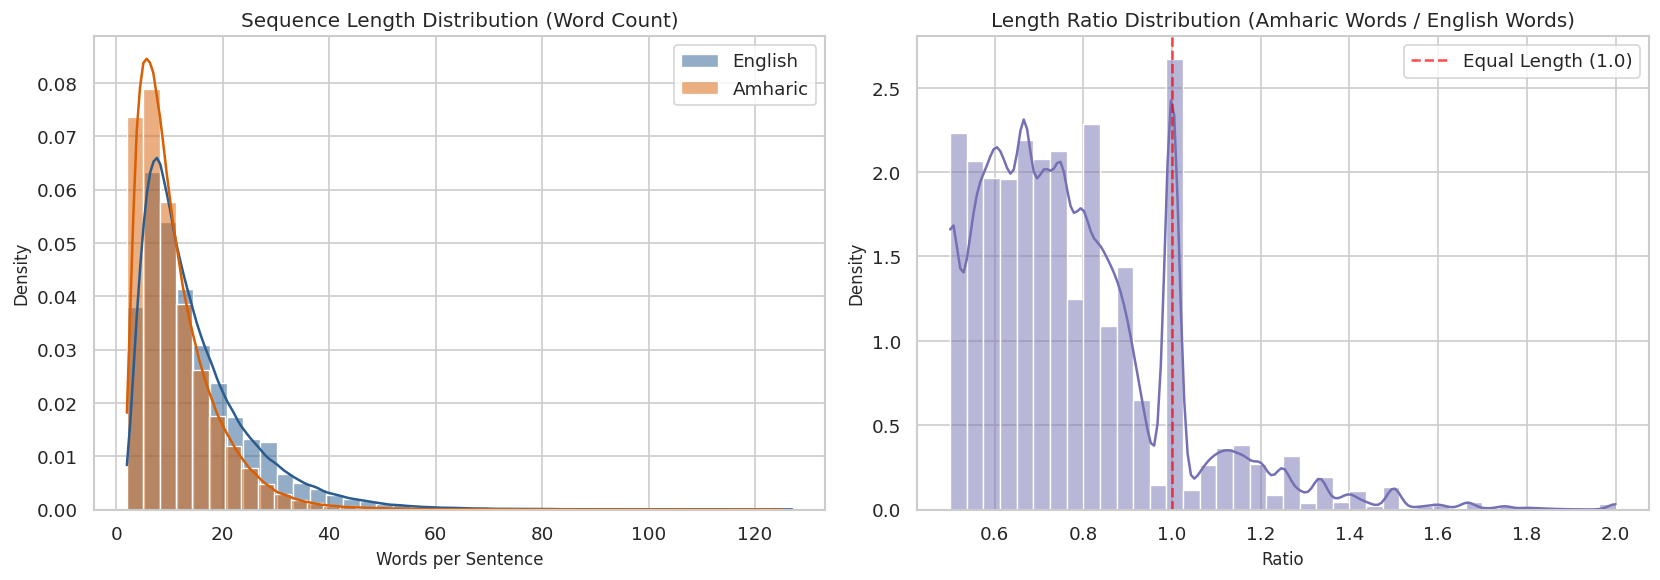

In [19]:
# Vocabulary and corpus summary statistics
total_words_am = df_clean["am_words"].sum()
total_words_en = df_clean["en_words"].sum()
unique_words_am = df_clean["amharic"].str.split(expand=True).stack().nunique()
unique_words_en = df_clean["english"].str.split(expand=True).stack().nunique()

print("=" * 70)
print("📚 CORPUS LEXICAL STATISTICS")
print("=" * 70)
print(f"• Total Clean Pairs           : {len(df_clean):,}")
print(f"• Total Words in Amharic      : {total_words_am:,}")
print(f"• Total Words in English      : {total_words_en:,}")
print(f"• Unique Words in Amharic     : {unique_words_am:,}")
print(f"• Unique Words in English     : {unique_words_en:,}")
print(f"• Type-Token Ratio (Amharic)  : {unique_words_am / total_words_am:.4f}")
print(f"• Type-Token Ratio (English)  : {unique_words_en / total_words_en:.4f}")
print("=" * 70)

# Statistical percentiles for sequence lengths
stats_df = pd.DataFrame({
    "Amharic Words": df_clean["am_words"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]),
    "English Words": df_clean["en_words"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]),
    "Length Ratio (AM/EN)": df_clean["len_ratio"].quantile([0.50, 0.75, 0.90, 0.95, 0.99])
})
stats_df.index = ["P50 (Median)", "P75", "P90", "P95", "P99"]
print()
print("Sequence Length Percentiles:")
display(stats_df)

# EDA Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Word length distributions
sns.histplot(df_clean["en_words"], ax=axes[0], color="#2b5c8f", label="English", kde=True, bins=40, stat="density")
sns.histplot(df_clean["am_words"], ax=axes[0], color="#d95f02", label="Amharic", kde=True, bins=40, stat="density")
axes[0].set_title("Sequence Length Distribution (Word Count)")
axes[0].set_xlabel("Words per Sentence")
axes[0].set_ylabel("Density")
axes[0].legend()

# 2. Length ratio distribution
sns.histplot(df_clean["len_ratio"], ax=axes[1], color="#7570b3", kde=True, bins=40, stat="density")
axes[1].axvline(1.0, color="red", linestyle="--", alpha=0.7, label="Equal Length (1.0)")
axes[1].set_title("Length Ratio Distribution (Amharic Words / English Words)")
axes[1].set_xlabel("Ratio")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Dataset Partitioning & Split Isolation Verification

We partition the curated corpus into:
* **Train Set (90%)**: Used for BPE subword tokenizer training and Transformer model training.
* **Validation Set (5%)**: Held out for validation loss monitoring and early stopping.
* **Test Set (5%)**: Held out strictly for final evaluation.

**Split Isolation Guarantee**: We rigorously compute set intersections between all partitions to prove **zero data leakage** ($\text{Train} \cap \text{Val} = \emptyset$, $\text{Train} \cap \text{Test} = \emptyset$, $\text{Val} \cap \text{Test} = \emptyset$).


In [21]:
# Partitioning dataset with fixed seed
df_train, df_temp = train_test_split(df_clean, test_size=0.10, random_state=SEED, shuffle=True)
df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=SEED, shuffle=True)

df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("=" * 70)
print("📦 DATASET PARTITIONS")
print("=" * 70)
print(f"• Training Set    : {len(df_train):>10,} pairs ({len(df_train) / len(df_clean) * 100:>5.1f}%)")
print(f"• Validation Set  : {len(df_val):>10,} pairs ({len(df_val) / len(df_clean) * 100:>5.1f}%)")
print(f"• Test Set        : {len(df_test):>10,} pairs ({len(df_test) / len(df_clean) * 100:>5.1f}%)")
print(f"• Total           : {len(df_clean):>10,} pairs")
print("=" * 70)

# Set intersection check for split isolation
train_keys = set(df_train["amharic"] + "|||" + df_train["english"])
val_keys = set(df_val["amharic"] + "|||" + df_val["english"])
test_keys = set(df_test["amharic"] + "|||" + df_test["english"])

overlap_tv = len(train_keys & val_keys)
overlap_tt = len(train_keys & test_keys)
overlap_vt = len(val_keys & test_keys)

print()
print("Data Leakage & Split Isolation Verification:")
print(f"• Train ∩ Val Overlap  : {overlap_tv} pairs")
print(f"• Train ∩ Test Overlap : {overlap_tt} pairs")
print(f"• Val ∩ Test Overlap   : {overlap_vt} pairs")

assert overlap_tv == 0 and overlap_tt == 0 and overlap_vt == 0, "Data leakage detected across splits!"
print("Zero overlap across all dataset partitions — isolation verified.")


📦 DATASET PARTITIONS
• Training Set    :    354,268 pairs ( 90.0%)
• Validation Set  :     19,682 pairs (  5.0%)
• Test Set        :     19,682 pairs (  5.0%)
• Total           :    393,632 pairs

Data Leakage & Split Isolation Verification:
• Train ∩ Val Overlap  : 0 pairs
• Train ∩ Test Overlap : 0 pairs
• Val ∩ Test Overlap   : 0 pairs
Zero overlap across all dataset partitions — isolation verified.


## 8. Joint Byte-Pair Encoding (BPE) Tokenizer Architecture & Training

We construct a joint Byte-Pair Encoding tokenizer using Hugging Face's high-performance Rust `tokenizers` backend:
* **Target Vocabulary Size**: 32,000 subwords.
* **Pre-Tokenizer**: `pre_tokenizers.Metaspace(replacement=" ", prepend_scheme="always")` for explicit space tracking.
* **Normalizer**: `normalizers.Sequence([normalizers.NFC()])` for canonical Unicode composition.
* **Decoder**: `decoders.Sequence([decoders.ByteFallback(), decoders.Metaspace(...)])` ensuring 100% reversible lossless roundtrips.
* **Special Tokens**: `<pad>=0`, `<unk>=1`, `<bos>=2`, `<eos>=3`, `<mask_src>=4`, `<2en>=5`, `<2am>=6`.
* **Alphabet Initialization**: Includes all printable ASCII characters and the complete Ethiopic Unicode block (`0x1200` to `0x137F`).


In [22]:
# Construct the Joint BPE Tokenizer
VOCAB_SIZE = 32000
MIN_FREQUENCY = 2

SPECIAL_TOKENS = [
    "<pad>",       # 0: Padding token
    "<unk>",       # 1: Out-of-vocabulary unknown token
    "<bos>",       # 2: Beginning of sequence (decoder start token)
    "<eos>",       # 3: End of sequence token
    "<mask_src>",   # 4: Mask token
    "<2en>",       # 5: Direction token targeting English
    "<2am>",       # 6: Direction token targeting Amharic
]

# Instantiate tokenizer with Byte-Fallback enabled BPE
tokenizer = Tokenizer(models.BPE(unk_token="<unk>", byte_fallback=True))
tokenizer.normalizer = normalizers.Sequence([normalizers.NFC()])
tokenizer.pre_tokenizer = pre_tokenizers.Metaspace(replacement=" ", prepend_scheme="always")
tokenizer.decoder = decoders.Sequence([
    decoders.ByteFallback(),
    decoders.Metaspace(replacement=" ", prepend_scheme="always")
])

# Initialize alphabet with ASCII printable characters + full Ethiopic Unicode block
initial_alphabet = (
    [chr(i) for i in range(32, 127)] +
    [chr(i) for i in range(0x1200, 0x1380)]
)

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    min_frequency=MIN_FREQUENCY,
    special_tokens=SPECIAL_TOKENS,
    initial_alphabet=initial_alphabet,
    show_progress=True
)

# Stream training text iterator over the training split
def corpus_iterator(batch_size: int = 10_000) -> Generator[List[str], None, None]:
    for i in range(0, len(df_train), batch_size):
        batch_am = df_train["amharic"].iloc[i:i + batch_size].tolist()
        batch_en = df_train["english"].iloc[i:i + batch_size].tolist()
        yield batch_am + batch_en

print("Starting Joint 32k BPE Tokenizer training on training split...")
start_time = time.time()
tokenizer.train_from_iterator(corpus_iterator(), trainer=trainer)
train_duration = time.time() - start_time
print(f"Tokenizer training completed in {train_duration:.2f} seconds.")

# Attach Template Post-Processor for standard sequence formatting
tokenizer.post_processor = processors.TemplateProcessing(
    single="$A",
    pair="$A $B",
    special_tokens=[(tok, tokenizer.token_to_id(tok)) for tok in SPECIAL_TOKENS]
)

# Verify canonical special token indices
print()
print("Special Token Verification:")
for expected_id, tok in enumerate(SPECIAL_TOKENS):
    actual_id = tokenizer.token_to_id(tok)
    assert actual_id == expected_id, f"Special token mismatch: {tok} expected {expected_id}, got {actual_id}"
    print(f"  • {tok:<12} -> ID {actual_id}")

# Save tokenizer model artifact
TOKENIZER_PATH = TOKENIZER_DIR / "joint_bpe_32k.json"
tokenizer.save(str(TOKENIZER_PATH))
print()
print(f"Saved tokenizer artifact to: {TOKENIZER_PATH.resolve()}")


Starting Joint 32k BPE Tokenizer training on training split...
Tokenizer training completed in 22.49 seconds.

Special Token Verification:
  • <pad>        -> ID 0
  • <unk>        -> ID 1
  • <bos>        -> ID 2
  • <eos>        -> ID 3
  • <mask_src>   -> ID 4
  • <2en>        -> ID 5
  • <2am>        -> ID 6

Saved tokenizer artifact to: /content/drive/MyDrive/Internship/MT/Data/artifacts/tokenizers/joint_bpe_32k.json


## 9. Empirical Tokenizer Evaluation & Diagnostics

We conduct four rigorous empirical diagnostic evaluations:
1. **Subword Fertility Analysis**:
   $$\text{Fertility} = \frac{\text{Number of Subwords}}{\text{Number of Words}}$$
   Ideal targets: $\sim 1.2\text{--}1.8$ for English, $\sim 1.8\text{--}2.8$ for Amharic.
2. **Zero-Contamination Out-of-Vocabulary (OOV) Rate on FLORES-200**:
   Measures lexical coverage on held-out gold human translation benchmarks.
3. **Subword Length & Script Distribution**:
   Analyzes vocabulary allocation across Ethiopic, Latin, and numeric/punctuation subwords.
4. **Reversible Lossless Roundtrip Verification**:
   Verifies that $\text{decode}(\text{encode}(x)) \equiv x$ holds without character dropping or spacing artifacts.


📈 SUBWORD FERTILITY ANALYSIS (Subwords / Word)
• Amharic Mean Fertility   : 1.48 ± 0.36 (Median: 1.42, P95: 2.12)
• English Mean Fertility   : 1.23 ± 0.29 (Median: 1.15, P95: 1.75)


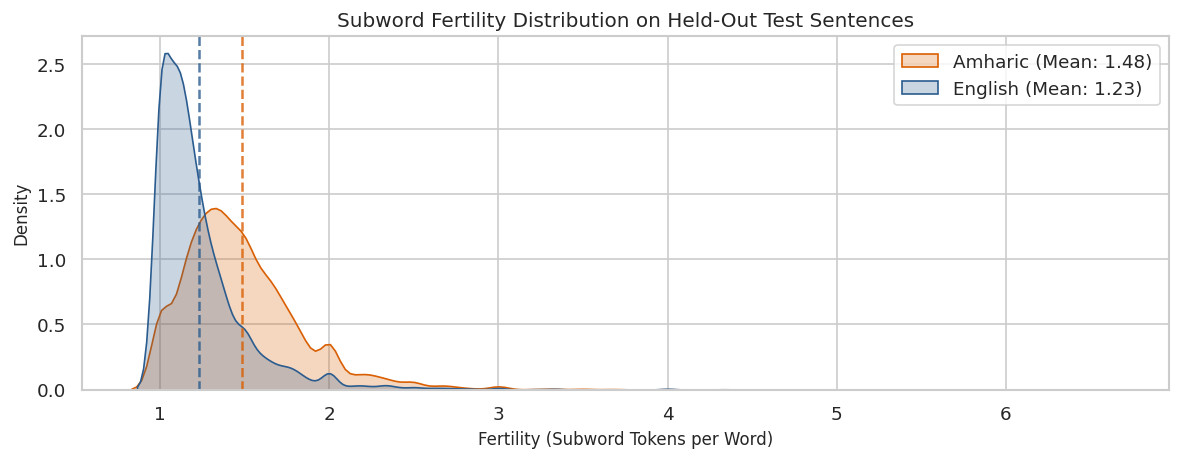

In [23]:
# 1. Fertility Analysis on Test Split
sample_eval = df_test.sample(n=min(10_000, len(df_test)), random_state=SEED)

am_fertility = []
en_fertility = []

for am, en in zip(sample_eval["amharic"], sample_eval["english"]):
    am_subwords = len(tokenizer.encode(am).ids)
    en_subwords = len(tokenizer.encode(en).ids)

    am_w = len(am.split())
    en_w = len(en.split())

    if am_w > 0:
        am_fertility.append(am_subwords / am_w)
    if en_w > 0:
        en_fertility.append(en_subwords / en_w)

am_fert = np.array(am_fertility)
en_fert = np.array(en_fertility)

print("=" * 70)
print("📈 SUBWORD FERTILITY ANALYSIS (Subwords / Word)")
print("=" * 70)
print(f"• Amharic Mean Fertility   : {am_fert.mean():.2f} ± {am_fert.std():.2f} (Median: {np.median(am_fert):.2f}, P95: {np.percentile(am_fert, 95):.2f})")
print(f"• English Mean Fertility   : {en_fert.mean():.2f} ± {en_fert.std():.2f} (Median: {np.median(en_fert):.2f}, P95: {np.percentile(en_fert, 95):.2f})")
print("=" * 70)

# Fertility Distribution Plot
plt.figure(figsize=(10, 4))
sns.kdeplot(am_fert, color="#d95f02", fill=True, label=f"Amharic (Mean: {am_fert.mean():.2f})")
sns.kdeplot(en_fert, color="#2b5c8f", fill=True, label=f"English (Mean: {en_fert.mean():.2f})")
plt.title("Subword Fertility Distribution on Held-Out Test Sentences")
plt.xlabel("Fertility (Subword Tokens per Word)")
plt.ylabel("Density")
plt.axvline(am_fert.mean(), color="#d95f02", linestyle="--", alpha=0.8)
plt.axvline(en_fert.mean(), color="#2b5c8f", linestyle="--", alpha=0.8)
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
# 2. Out-of-Vocabulary (OOV) Rate on Held-Out FLORES-200 Benchmark
UNK_ID = tokenizer.token_to_id("<unk>")

if df_flores is not None and len(df_flores) > 0:
    print(f"Evaluating OOV rate on {len(df_flores):,} gold FLORES-200 benchmark pairs...")
    flores_am_tokens = 0
    flores_en_tokens = 0
    flores_am_unks = 0
    flores_en_unks = 0

    for am, en in zip(df_flores["amharic"], df_flores["english"]):
        am_ids = tokenizer.encode(clean_amharic_text(am)).ids
        en_ids = tokenizer.encode(clean_english_text(en)).ids

        flores_am_tokens += len(am_ids)
        flores_en_tokens += len(en_ids)
        flores_am_unks += am_ids.count(UNK_ID)
        flores_en_unks += en_ids.count(UNK_ID)

    am_oov_rate = (flores_am_unks / flores_am_tokens) * 100 if flores_am_tokens > 0 else 0
    en_oov_rate = (flores_en_unks / flores_en_tokens) * 100 if flores_en_tokens > 0 else 0

    print("=" * 70)
    print("🎯 FLORES-200 BENCHMARK ZERO-CONTAMINATION OOV REPORT")
    print("=" * 70)
    print(f"• Amharic Tokens Evaluated : {flores_am_tokens:,}")
    print(f"• Amharic <unk> Tokens     : {flores_am_unks:,} ({am_oov_rate:.4f}%)")
    print(f"• English Tokens Evaluated : {flores_en_tokens:,}")
    print(f"• English <unk> Tokens     : {flores_en_unks:,} ({en_oov_rate:.4f}%)")
    print("=" * 70)
else:
    # Test on test split if flores benchmark was not present
    print("Evaluating OOV rate on held-out test split...")
    test_am_tokens = sum(len(tokenizer.encode(s).ids) for s in df_test["amharic"].iloc[:5000])
    test_am_unks = sum(tokenizer.encode(s).ids.count(UNK_ID) for s in df_test["amharic"].iloc[:5000])
    test_en_tokens = sum(len(tokenizer.encode(s).ids) for s in df_test["english"].iloc[:5000])
    test_en_unks = sum(tokenizer.encode(s).ids.count(UNK_ID) for s in df_test["english"].iloc[:5000])
    print(f"• Amharic Test UNK Rate : {test_am_unks / test_am_tokens * 100:.4f}% ({test_am_unks} unks / {test_am_tokens:,} tokens)")
    print(f"• English Test UNK Rate : {test_en_unks / test_en_tokens * 100:.4f}% ({test_en_unks} unks / {test_en_tokens:,} tokens)")


Evaluating OOV rate on 6,027 gold FLORES-200 benchmark pairs...
🎯 FLORES-200 BENCHMARK ZERO-CONTAMINATION OOV REPORT
• Amharic Tokens Evaluated : 164,604
• Amharic <unk> Tokens     : 3 (0.0018%)
• English Tokens Evaluated : 247,894
• English <unk> Tokens     : 3 (0.0012%)


In [25]:
# 3. Vocabulary Script Composition & Subword Length Analysis
vocab = tokenizer.get_vocab()
actual_vocab_size = len(vocab)

ethiopic_re = re.compile(r"[ሀ-፿ᎀ-᎙ⶀ-⷟]")
latin_re = re.compile(r"[a-zA-Z]")
digit_re = re.compile(r"[0-9]")

ethiopic_count = 0
latin_count = 0
numeric_punct_count = 0
special_count = len(SPECIAL_TOKENS)

subword_lengths = []

for token, tid in vocab.items():
    if token in SPECIAL_TOKENS:
        continue
    clean_tok = token.replace(" ", "")
    subword_lengths.append(len(clean_tok))
    if ethiopic_re.search(clean_tok):
        ethiopic_count += 1
    elif latin_re.search(clean_tok):
        latin_count += 1
    else:
        numeric_punct_count += 1

print("=" * 70)
print("📊 32K VOCABULARY SCRIPT DISTRIBUTION")
print("=" * 70)
print(f"• Total Vocabulary Size       : {actual_vocab_size:,}")
print(f"• Ethiopic Script Subwords    : {ethiopic_count:>7,} ({ethiopic_count / actual_vocab_size * 100:>5.2f}%)")
print(f"• Latin Script Subwords       : {latin_count:>7,} ({latin_count / actual_vocab_size * 100:>5.2f}%)")
print(f"• Numeric & Symbol Subwords   : {numeric_punct_count:>7,} ({numeric_punct_count / actual_vocab_size * 100:>5.2f}%)")
print(f"• Special Tokens              : {special_count:>7,} ({special_count / actual_vocab_size * 100:>5.2f}%)")
print(f"• Mean Subword Length         : {np.mean(subword_lengths):.2f} characters")
print("=" * 70)


📊 32K VOCABULARY SCRIPT DISTRIBUTION
• Total Vocabulary Size       : 32,000
• Ethiopic Script Subwords    :  17,001 (53.13%)
• Latin Script Subwords       :  13,176 (41.17%)
• Numeric & Symbol Subwords   :   1,816 ( 5.67%)
• Special Tokens              :       7 ( 0.02%)
• Mean Subword Length         : 4.17 characters


In [26]:
# 4. Reversible Lossless Roundtrip Verification
roundtrip_test_sentences = [
    "ጠቅላይ ሚኒስትሩ በአዲስ አበባ አዳዲስ የኢኮኖሚ ማሻሻያዎችን አስታወቁ።",
    "The 2026 conference was held in Addis Ababa with over 20,000 participants.",
    "ዶክተር አብይ አህመድ ታላቁን የኢትዮጵያ ህዳሴ ግድብ ጎበኙ።",
    "Peace and economic prosperity are essential for regional integration.",
    "ዋጋው 3.14 ዶላር ሲሆን ሰዓቱ 10:30 ነበር፤ ስብሰባውም ተጠናቀቀ።"
]

print("Lossless Roundtrip Reconstruction Suite:")
all_exact = True

for text in roundtrip_test_sentences:
    encoded = tokenizer.encode(text)
    decoded = tokenizer.decode(encoded.ids)
    is_match = (decoded.strip() == text.strip())
    if not is_match:
        all_exact = False
    status = "EXACT" if is_match else "MISMATCH"
    print()
    print(f"[{status}] Original: {text}")
    print(f"        Tokens  : {encoded.tokens[:10]}... ({len(encoded.tokens)} total tokens)")
    print(f"        Decoded : {decoded}")

assert all_exact, "Lossless reconstruction failed!"
print()
print("Reversible lossless roundtrip verified for all test cases.")


Lossless Roundtrip Reconstruction Suite:

[EXACT] Original: ጠቅላይ ሚኒስትሩ በአዲስ አበባ አዳዲስ የኢኮኖሚ ማሻሻያዎችን አስታወቁ።
        Tokens  : [' ጠቅላይ', ' ሚኒስትሩ', ' በአዲስ', ' አበባ', ' አዳዲስ', ' የኢኮኖሚ', ' ማሻሻያ', 'ዎችን', ' አስታወ', 'ቁ።']... (10 total tokens)
        Decoded : ጠቅላይ ሚኒስትሩ በአዲስ አበባ አዳዲስ የኢኮኖሚ ማሻሻያዎችን አስታወቁ።

[EXACT] Original: The 2026 conference was held in Addis Ababa with over 20,000 participants.
        Tokens  : [' The', ' 20', '26', ' conference', ' was', ' held', ' in', ' Add', 'is', ' Ab']... (18 total tokens)
        Decoded : The 2026 conference was held in Addis Ababa with over 20,000 participants.

[EXACT] Original: ዶክተር አብይ አህመድ ታላቁን የኢትዮጵያ ህዳሴ ግድብ ጎበኙ።
        Tokens  : [' ዶክተር', ' አብይ', ' አህመድ', ' ታላ', 'ቁን', ' የኢትዮጵያ', ' ህ', 'ዳሴ', ' ግድብ', ' ጎ']... (13 total tokens)
        Decoded : ዶክተር አብይ አህመድ ታላቁን የኢትዮጵያ ህዳሴ ግድብ ጎበኙ።

[EXACT] Original: Peace and economic prosperity are essential for regional integration.
        Tokens  : [' Peace', ' and', ' economic', ' prosper', 'ity', ' are',

## 10. Bidirectional Sequence Tokenization & Parquet Export

We convert the parallel corpus into bidirectional sequence-to-sequence training pairs with target direction indicator tokens:
* **$\text{AM} \to \text{EN}$**: $\text{src} = [\text{<2en>}] + \text{AM\_IDs} + [\text{<eos>}]$, $\text{tgt} = [\text{<bos>}] + \text{EN\_IDs} + [\text{<eos>}]$
* **$\text{EN} \to \text{AM}$**: $\text{src} = [\text{<2am>}] + \text{EN\_IDs} + [\text{<eos>}]$, $\text{tgt} = [\text{<bos>}] + \text{AM\_IDs} + [\text{<eos>}]$

The tokenized datasets are exported directly to Parquet format (`train_ids.parquet`, `val_ids.parquet`, `test_ids.parquet`) for high-throughput zero-overhead streaming during Transformer training.


In [27]:
# Build bidirectional training examples
TO_EN_ID = tokenizer.token_to_id("<2en>")
TO_AM_ID = tokenizer.token_to_id("<2am>")
BOS_ID = tokenizer.token_to_id("<bos>")
EOS_ID = tokenizer.token_to_id("<eos>")
MAX_SEQ_LEN = 128

def build_bidirectional_dataframe(df_in: pd.DataFrame, desc: str = "Tokenizing") -> pd.DataFrame:
    records = []
    for _, row in tqdm(df_in.iterrows(), total=len(df_in), desc=desc):
        am_ids = tokenizer.encode(row["amharic"]).ids
        en_ids = tokenizer.encode(row["english"]).ids

        # Enforce maximum sequence length constraint
        if len(am_ids) > (MAX_SEQ_LEN - 2) or len(en_ids) > (MAX_SEQ_LEN - 2):
            continue

        # 1. Amharic -> English: prefix <2en> on source, <bos> on target
        records.append({
            "direction": "am2en",
            "src_ids": [TO_EN_ID] + am_ids + [EOS_ID],
            "tgt_ids": [BOS_ID] + en_ids + [EOS_ID],
            "src_len": len(am_ids) + 2,
            "tgt_len": len(en_ids) + 2
        })

        # 2. English -> Amharic: prefix <2am> on source, <bos> on target
        records.append({
            "direction": "en2am",
            "src_ids": [TO_AM_ID] + en_ids + [EOS_ID],
            "tgt_ids": [BOS_ID] + am_ids + [EOS_ID],
            "src_len": len(en_ids) + 2,
            "tgt_len": len(am_ids) + 2
        })

    return pd.DataFrame(records)

print("Building bidirectional tokenized datasets...")
train_bidir = build_bidirectional_dataframe(df_train, desc="Tokenizing Train Split")
val_bidir = build_bidirectional_dataframe(df_val, desc="Tokenizing Val Split")
test_bidir = build_bidirectional_dataframe(df_test, desc="Tokenizing Test Split")

print()
print("=" * 70)
print("📦 BIDIRECTIONAL TOKENIZED DATASET SUMMARY")
print("=" * 70)
print(f"• Train Examples : {len(train_bidir):>10,} ({len(df_train):,} parallel pairs × 2 directions)")
print(f"• Val Examples   : {len(val_bidir):>10,} ({len(df_val):,} parallel pairs × 2 directions)")
print(f"• Test Examples  : {len(test_bidir):>10,} ({len(df_test):,} parallel pairs × 2 directions)")
print(f"• Mean Token Length (Source) : {train_bidir['src_len'].mean():.1f} tokens")
print(f"• Mean Token Length (Target) : {train_bidir['tgt_len'].mean():.1f} tokens")
print(f"• P95 Token Length (Source)  : {train_bidir['src_len'].quantile(0.95):.0f} tokens")
print(f"• P95 Token Length (Target)  : {train_bidir['tgt_len'].quantile(0.95):.0f} tokens")
print("=" * 70)

# Save to Parquet format
train_path = TOKENIZED_DIR / "train_ids.parquet"
val_path = TOKENIZED_DIR / "val_ids.parquet"
test_path = TOKENIZED_DIR / "test_ids.parquet"

train_bidir.to_parquet(train_path, index=False)
val_bidir.to_parquet(val_path, index=False)
test_bidir.to_parquet(test_path, index=False)

print()
print(f"Successfully exported tokenized datasets to {TOKENIZED_DIR}:")
print(f"  • {train_path.name} ({train_path.stat().st_size / (1024**2):.2f} MB)")
print(f"  • {val_path.name} ({val_path.stat().st_size / (1024**2):.2f} MB)")
print(f"  • {test_path.name} ({test_path.stat().st_size / (1024**2):.2f} MB)")


Building bidirectional tokenized datasets...


Tokenizing Train Split:   0%|          | 0/354268 [00:00<?, ?it/s]

Tokenizing Val Split:   0%|          | 0/19682 [00:00<?, ?it/s]

Tokenizing Test Split:   0%|          | 0/19682 [00:00<?, ?it/s]


📦 BIDIRECTIONAL TOKENIZED DATASET SUMMARY
• Train Examples :    708,196 (354,268 parallel pairs × 2 directions)
• Val Examples   :     39,344 (19,682 parallel pairs × 2 directions)
• Test Examples  :     39,346 (19,682 parallel pairs × 2 directions)
• Mean Token Length (Source) : 18.7 tokens
• Mean Token Length (Target) : 18.7 tokens
• P95 Token Length (Source)  : 41 tokens
• P95 Token Length (Target)  : 41 tokens

Successfully exported tokenized datasets to /content/drive/MyDrive/Internship/MT/Data/data/processed/tokenized:
  • train_ids.parquet (51.09 MB)
  • val_ids.parquet (3.06 MB)
  • test_ids.parquet (3.08 MB)


## 11. Architectural Summary & Handoff Checklist

### 📋 Tokenizer & Preprocessing Deliverables

| Asset | Location | Description |
|:---|:---|:---|
| **Tokenizer Artifact** | `artifacts/tokenizers/joint_bpe_32k.json` | Hugging Face 32,000 BPE tokenizer with Metaspace pre-tokenization and byte fallback. |
| **Train Dataset** | `data/processed/tokenized/train_ids.parquet` | Bidirectional tokenized training pairs with direction tags (`<2en>`, `<2am>`). |
| **Validation Dataset** | `data/processed/tokenized/val_ids.parquet` | Held-out validation split for loss tracking and early stopping. |
| **Test Dataset** | `data/processed/tokenized/test_ids.parquet` | Held-out test split for final BLEU/chrF evaluation. |

### 🚀 Transformer Architecture Configuration
* **Vocab Size ($|V|$)**: `32,000`
* **Special Token IDs**:
  * `<pad>` = `0`
  * `<unk>` = `1`
  * `<bos>` = `2`
  * `<eos>` = `3`
  * `<mask_src>` = `4`
  * `<2en>` = `5`
  * `<2am>` = `6`
* **Max Sequence Length**: `128`
* **Weight Tying**: **3-way** ($E_{\text{src}} = E_{\text{tgt}} = W_{\text{proj}}^T$), yielding $32.7\text{M}$ parameter savings.

---
*Ready for model architecture implementation, bucket batch sampling, and Transformer training.*
